In [47]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [48]:
df = df[df['job_title_short'] == 'Data Analyst']

In [49]:
# Data Analyst jobs only
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

# Remove rows with no salary
df_DA = df_DA.dropna(subset=['salary_year_avg'])

# One skill per row
df_DA = df_DA.explode('job_skills')

# Calculate statistics
skills_stats = df_DA.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

# Top 10 most common skills
skills_stats = skills_stats.sort_values(
    by='skill_count',
    ascending=False
).head(10)

skills_stats

,skill_count,median_salary
job_skills,,
sql,3079,92500.0
excel,2135,84479.0
python,1838,98500.0
tableau,1657,95000.0
r,1073,92527.5
power bi,1042,90000.0
sas,1006,90000.0
word,523,80000.0
powerpoint,518,85000.0


In [50]:
 df_exploded = df.explode('job_skills')



In [51]:
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)  

skill_stats = skill_stats.sort_values(by = 'skill_count', ascending = False).head(10)

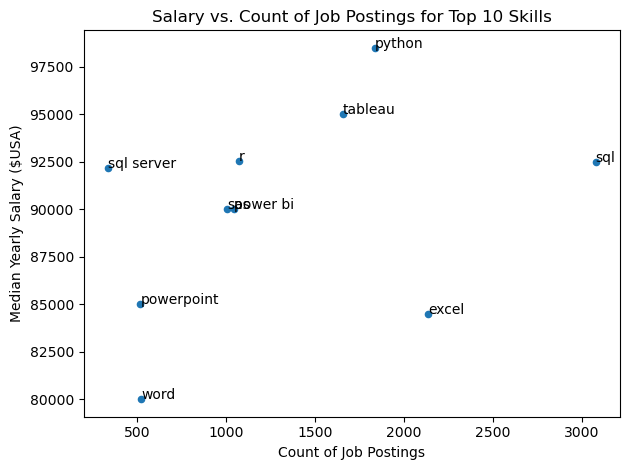

In [53]:
skills_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USA)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()

for i, txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], txt)

plt.show()


<Axes: xlabel='skill_count', ylabel='skill_pay'>

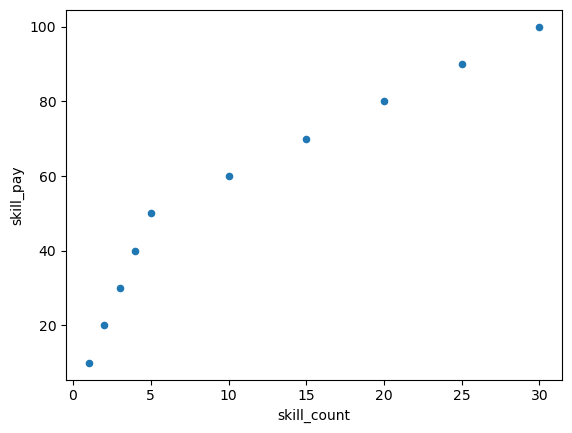

In [ ]:
data = {
    'job_skills': ['python', 'sql', 'java', 'c++', 'c#', 'javascript', 'html', 'css', 'php', 'ruby'],
    'skill_count': [30, 25, 20, 15, 10, 5, 4, 3, 2, 1],
    'skill_pay': [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
}

df = pd.DataFrame(data)

df.plot(kind = 'scatter', x = 'skill_count', y = 'skill_pay')